<!-- notebook/markdown_cell_1.md -->
# Case Study: Detecting Fraudulent Credit Card Transactions
**Course:** DLMDSME01 – Model Engineering  
**Objective:** Evaluate machine learning pipelines, resampling techniques (SMOTE), and hyperparameter optimization for imbalanced classification.

This notebook executes the data processing, model training, and evaluation required for the case study. The workflow ensures no data leakage occurs during cross-validation by utilizing `imblearn` pipelines. The dataset will be downloaded automatically if not present locally.

In [1]:
# notebook/code_cell_1.py
# Import necessary libraries
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-Learn and OpenML modules
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import (
    precision_score, recall_score, f1_score, 
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    PrecisionRecallDisplay
)

# Imbalanced-Learn pipeline (CRITICAL: prevents data leakage during CV)
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

# Classifiers
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier

# Suppress warnings for cleaner output
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
plt.style.use('ggplot')
sns.set_palette("muted")

<!-- notebook/markdown_cell_2.md -->
## 1. Automated Data Loading and Exploratory Data Analysis (EDA)
We load the ULB Credit Card Fraud dataset. To prevent manual downloading, the code checks if `creditcard.csv` exists locally. If not, it automatically fetches the exact dataset from OpenML (ID: 1597) and saves it to a CSV file for future runs.

Dataset not found locally. Downloading from OpenML (this may take a few minutes)...
Download complete! Saved to 'creditcard.csv'.

Dataset Shape: (284807, 30)
Total missing values: 0

Class Distribution:
Legitimate (0): 284315
Fraudulent (1): 492
Fraud Rate: 0.173%


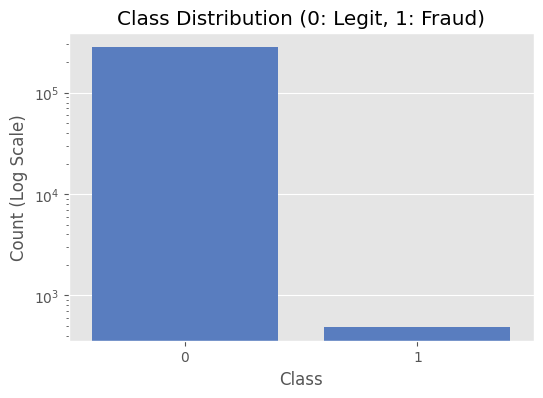

In [2]:
# notebook/code_cell_2.py
file_path = 'creditcard.csv'

# Automated Download Logic
if not os.path.exists(file_path):
    print("Dataset not found locally. Downloading from OpenML (this may take a few minutes)...")
    # Fetching the dataset (OpenML ID 1597 corresponds to the ULB Credit Card Fraud dataset)
    data = fetch_openml(data_id=1597, as_frame=True, parser='auto')
    df = data.frame
    
    # OpenML formats the target as a categorical string ('0' and '1'). Convert to integer.
    df['Class'] = df['Class'].astype(int)
    
    # Save locally to prevent re-downloading in future runs
    df.to_csv(file_path, index=False)
    print(f"Download complete! Saved to '{file_path}'.")
else:
    print(f"Dataset found locally at '{file_path}'. Loading...")
    df = pd.read_csv(file_path)

# Basic EDA
print(f"\nDataset Shape: {df.shape}")

# Check for missing values
missing_values = df.isnull().sum().sum()
print(f"Total missing values: {missing_values}")

# Class distribution
class_counts = df['Class'].value_counts()
fraud_rate = (class_counts[1] / len(df)) * 100

print("\nClass Distribution:")
print(f"Legitimate (0): {class_counts[0]}")
print(f"Fraudulent (1): {class_counts[1]}")
print(f"Fraud Rate: {fraud_rate:.3f}%")

# Visualize the imbalance
plt.figure(figsize=(6, 4))
sns.countplot(x='Class', data=df)
plt.title("Class Distribution (0: Legit, 1: Fraud)")
plt.yscale('log') # Log scale because of extreme imbalance
plt.ylabel("Count (Log Scale)")
plt.show()

<!-- notebook/markdown_cell_3.md -->
## 2. Data Preprocessing and Splitting
To prepare the data for our models, we will:
1. Separate features (`X`) and the target label (`y`).
2. Split the data into an 80/20 train-test partition using **stratification** to ensure the 0.17% fraud rate is preserved in both sets.
3. We will handle feature scaling (using `RobustScaler` to handle outliers in the `Amount` feature) directly inside our pipelines later.

In [3]:
# notebook/code_cell_3.py
# Separate features and target
X = df.drop(columns=['Class'])
y = df['Class']

# Stratified Train-Test Split (80-20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f"Training set shape: {X_train.shape}")
print(f"Testing set shape: {X_test.shape}")
print(f"Fraud cases in training set: {sum(y_train)}")
print(f"Fraud cases in testing set: {sum(y_test)}")

Training set shape: (227845, 29)
Testing set shape: (56962, 29)
Fraud cases in training set: 394
Fraud cases in testing set: 98


<!-- notebook/markdown_cell_4.md -->
## 3. Pipeline Construction
As required by the assignment, we construct pipelines to avoid data leakage. If we apply SMOTE to the entire dataset before Cross-Validation (CV), synthetic samples will bleed into the validation folds, causing artificially high performance. The `imblearn.pipeline` applies SMOTE *only* to the training folds during CV.

We define four pipelines to fulfill the ablation study requirements:
1. **LR Baseline:** Logistic Regression without SMOTE.
2. **LR SMOTE:** Logistic Regression with SMOTE.
3. **XGB Baseline:** XGBoost without SMOTE.
4. **XGB SMOTE:** XGBoost with SMOTE.

In [4]:
# notebook/code_cell_4.py
# Define preprocessing and resampling steps
scaler = RobustScaler()
smote = SMOTE(random_state=42)

# Define classifiers
lr = LogisticRegression(max_iter=1000, random_state=42)
xgb = XGBClassifier(eval_metric='logloss', random_state=42)

# 1. Logistic Regression Pipelines
pipe_lr_base = ImbPipeline([('scaler', scaler), ('clf', lr)])
pipe_lr_smote = ImbPipeline([('scaler', scaler), ('smote', smote), ('clf', lr)])

# 2. XGBoost Pipelines
pipe_xgb_base = ImbPipeline([('scaler', scaler), ('clf', xgb)])
pipe_xgb_smote = ImbPipeline([('scaler', scaler), ('smote', smote), ('clf', xgb)])

<!-- notebook/markdown_cell_5.md -->
## 4. Hyperparameter Optimization
We optimize the classifiers using `RandomizedSearchCV` with 5-fold cross-validation. This explores the hyperparameter space efficiently, saving computational time compared to Exhaustive Grid Search, which is critical given the size of this dataset.

In [5]:
# notebook/code_cell_5.py
# Dictionaries to store the best models and results
best_models = {}
results_list =[]

# Define hyperparameter grids
param_grid_lr = {
    'clf__C':[0.01, 0.1, 1, 10],
    'clf__class_weight':[None, 'balanced']
}

param_grid_xgb = {
    'clf__n_estimators':[100, 200],
    'clf__max_depth': [3, 5, 7],
    'clf__learning_rate': [0.01, 0.1, 0.2]
}

# Helper function to run RandomizedSearchCV and evaluate
def optimize_and_evaluate(name, pipeline, param_grid, X_train, y_train, X_test, y_test, n_iter=5):
    print(f"--- Optimizing {name} ---")
    search = RandomizedSearchCV(
        pipeline, param_distributions=param_grid, 
        n_iter=n_iter, cv=5, scoring='f1', 
        n_jobs=-1, random_state=42, verbose=1
    )
    search.fit(X_train, y_train)
    
    best_model = search.best_estimator_
    best_models[name] = best_model
    
    print(f"Best Parameters: {search.best_params_}")
    
    # Predict on Test Set
    y_pred = best_model.predict(X_test)
    
    # Calculate metrics
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    # Store results
    results_list.append({
        'Model': name,
        'Precision': round(precision, 4),
        'Recall': round(recall, 4),
        'F1-Score': round(f1, 4)
    })
    print(f"Test F1-Score: {f1:.4f}\n")

# Run Optimization
optimize_and_evaluate("LR Baseline", pipe_lr_base, param_grid_lr, X_train, y_train, X_test, y_test, n_iter=4)
optimize_and_evaluate("LR + SMOTE", pipe_lr_smote, param_grid_lr, X_train, y_train, X_test, y_test, n_iter=4)
optimize_and_evaluate("XGB Baseline", pipe_xgb_base, param_grid_xgb, X_train, y_train, X_test, y_test, n_iter=5)
optimize_and_evaluate("XGB + SMOTE", pipe_xgb_smote, param_grid_xgb, X_train, y_train, X_test, y_test, n_iter=5)

--- Optimizing LR Baseline ---
Fitting 5 folds for each of 4 candidates, totalling 20 fits
Best Parameters: {'clf__class_weight': None, 'clf__C': 0.01}
Test F1-Score: 0.7018

--- Optimizing LR + SMOTE ---
Fitting 5 folds for each of 4 candidates, totalling 20 fits
Best Parameters: {'clf__class_weight': 'balanced', 'clf__C': 0.01}
Test F1-Score: 0.1100

--- Optimizing XGB Baseline ---
Fitting 5 folds for each of 5 candidates, totalling 25 fits
Best Parameters: {'clf__n_estimators': 100, 'clf__max_depth': 5, 'clf__learning_rate': 0.1}
Test F1-Score: 0.8444

--- Optimizing XGB + SMOTE ---
Fitting 5 folds for each of 5 candidates, totalling 25 fits
Best Parameters: {'clf__n_estimators': 100, 'clf__max_depth': 5, 'clf__learning_rate': 0.1}
Test F1-Score: 0.3410



<!-- notebook/markdown_cell_6.md -->
## 5. Summary of Results
We consolidate the performance metrics (Precision, Recall, F1-Score) into a DataFrame. This table will be directly referenced in the LaTeX report.

In [6]:
# notebook/code_cell_6.py
# Convert results to DataFrame
results_df = pd.DataFrame(results_list)
display(results_df)

# Export to CSV for easy reference
results_df.to_csv('model_results.csv', index=False)

,Model,Precision,Recall,F1-Score
0,LR Baseline,0.8219,0.6122,0.7018
1,LR + SMOTE,0.0585,0.9184,0.1100
2,XGB Baseline,0.9268,0.7755,0.8444
3,XGB + SMOTE,0.2099,0.9082,0.3410


<!-- notebook/markdown_cell_7.md -->
## 6. Visual Analysis: Precision-Recall Curve & Confusion Matrix
For highly imbalanced datasets, the ROC curve can be overly optimistic. The Precision-Recall (PR) curve is the standard metric of choice. We will plot the PR curve and the Confusion Matrix for our best performing model.

Visualizing results for the best model: XGB Baseline


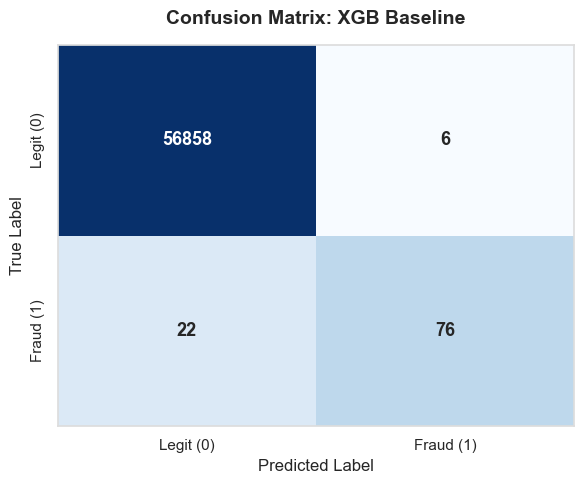

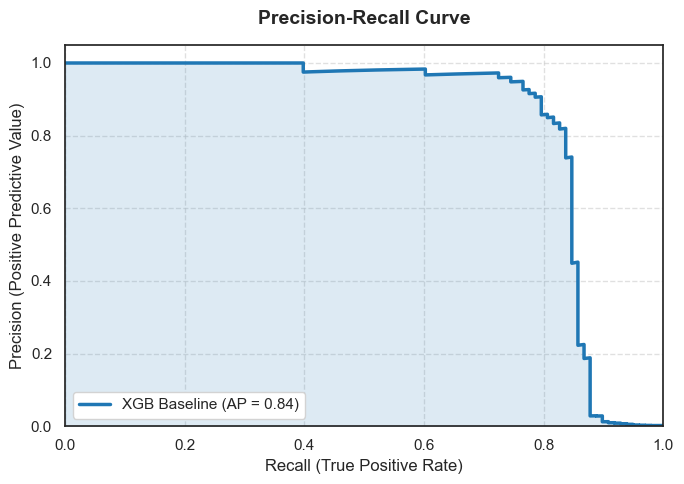

In [13]:
# notebook/code_cell_7.py
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LogNorm
from sklearn.metrics import confusion_matrix, precision_recall_curve, average_precision_score

# Select the best model based on F1-Score
best_model_name = results_df.loc[results_df['F1-Score'].idxmax()]['Model']
best_classifier = best_models[best_model_name]

print(f"Visualizing results for the best model: {best_model_name}")

# Generate predictions and probabilities for visualizations
y_pred = best_classifier.predict(X_test)
y_proba = best_classifier.predict_proba(X_test)[:, 1]

# --- Professional Plot Setup ---
sns.set_theme(style="white", rc={"axes.facecolor": (0, 0, 0, 0)})
primary_color = "#1f77b4" # Professional deep blue

# --- Plot 1: Log-Scaled Confusion Matrix ---
# Extreme class imbalance makes standard confusion matrices visually flat.
# We use a logarithmic color scale (LogNorm) so the critical minority class instances (False Negatives, True Positives)
# are visually distinct from the massive True Negative quadrant.
cm = confusion_matrix(y_test, y_pred)
fig1, ax1 = plt.subplots(figsize=(6, 5))

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", norm=LogNorm(), 
            cbar=False, ax=ax1, annot_kws={"size": 13, "weight": "bold"})

ax1.set_title(f"Confusion Matrix: {best_model_name}", fontsize=14, fontweight='bold', pad=15)
ax1.set_xlabel("Predicted Label", fontsize=12)
ax1.set_ylabel("True Label", fontsize=12)
ax1.set_xticklabels(['Legit (0)', 'Fraud (1)'])
ax1.set_yticklabels(['Legit (0)', 'Fraud (1)'], va='center')

for _, spine in ax1.spines.items():
    spine.set_visible(True)
    spine.set_color('#dddddd')
    
plt.tight_layout()
plt.savefig('images/confusion_matrix.png', dpi=300, bbox_inches='tight') # Save as PNG for Overleaf
plt.show()

# --- Plot 2: Filled Precision-Recall Curve ---
precision_vals, recall_vals, _ = precision_recall_curve(y_test, y_proba)
ap_score = average_precision_score(y_test, y_proba)

fig2, ax2 = plt.subplots(figsize=(7, 5))

ax2.plot(recall_vals, precision_vals, color=primary_color, lw=2.5, 
         label=f"{best_model_name} (AP = {ap_score:.2f})")

# Fill under the curve for a sleek, modern look
ax2.fill_between(recall_vals, precision_vals, alpha=0.15, color=primary_color)

ax2.set_title("Precision-Recall Curve", fontsize=14, fontweight='bold', pad=15)
ax2.set_xlabel("Recall (True Positive Rate)", fontsize=12)
ax2.set_ylabel("Precision (Positive Predictive Value)", fontsize=12)
ax2.set_xlim([0.0, 1.0])
ax2.set_ylim([0.0, 1.05])

ax2.grid(True, linestyle='--', alpha=0.6)
ax2.legend(loc='lower left', frameon=True, fontsize=11, facecolor='white', edgecolor='lightgray', framealpha=1)

plt.tight_layout()
plt.savefig('images/pr_curve.png', dpi=300, bbox_inches='tight') # Save as PNG for Overleaf
plt.show()

<!-- notebook/markdown_cell_8.md -->
## 7. Threshold-Moving Analysis (XGB Baseline)
To analyze the operational business trade-off, we evaluate the best model across various probability thresholds. Lowering the threshold increases Recall (catching more fraud) but decreases Precision (more false alarms).

In [11]:
# notebook/code_cell_8.py
# Extract probabilities for the positive class (fraud) from the best model
y_proba = best_classifier.predict_proba(X_test)[:, 1]

thresholds =[0.05, 0.10, 0.50, 0.80]
thresh_results =[]

for t in thresholds:
    # Apply custom threshold
    y_pred_t = (y_proba >= t).astype(int)
    
    thresh_results.append({
        'Threshold': t,
        'Precision': round(precision_score(y_test, y_pred_t), 4),
        'Recall': round(recall_score(y_test, y_pred_t), 4),
        'F1-Score': round(f1_score(y_test, y_pred_t), 4)
    })

# Display the threshold trade-offs
thresh_df = pd.DataFrame(thresh_results)
display(thresh_df)

,Threshold,Precision,Recall,F1-Score
0,0.05,0.7034,0.8469,0.7685
1,0.10,0.8351,0.8265,0.8308
2,0.50,0.9268,0.7755,0.8444
3,0.80,0.9481,0.7449,0.8343
